In [2]:
import os
print(os.getcwd())

c:\Users\Owner\OneDrive\Desktop\ev-efficiency-analysis\notebook\notebooks


In [3]:
print(os.listdir('.'))

['phase3_first_analysis.ipynb']


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("tesla_trip_data.csv")

df.head()

,trip_id,speed_mph,outside_temp_f,energy_used_kwh,distance_miles,wh_per_mile
0,1,35,70,6.2,25,248
1,2,45,72,8.1,31,261
2,3,55,68,10.4,38,274
3,4,65,75,14.2,45,315
4,5,75,80,18.5,50,370


In [11]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   trip_id          10 non-null     int64  
 1   speed_mph        10 non-null     int64  
 2   outside_temp_f   10 non-null     int64  
 3   energy_used_kwh  10 non-null     float64
 4   distance_miles   10 non-null     int64  
 5   wh_per_mile      10 non-null     int64  
dtypes: float64(1), int64(5)
memory usage: 612.0 bytes


,trip_id,speed_mph,outside_temp_f,energy_used_kwh,distance_miles,wh_per_mile
count,10.00000,10.00000,10.000000,10.000000,10.000000,10.000000
mean,5.50000,55.00000,67.000000,12.300000,37.900000,318.400000
std,3.02765,14.90712,20.596656,4.286153,9.350579,45.797137
min,1.00000,30.00000,35.000000,6.200000,22.000000,248.000000
25%,3.25000,46.25000,50.750000,8.675000,32.250000,283.250000
50%,5.50000,57.50000,71.000000,12.500000,40.000000,322.000000
75%,7.75000,65.00000,78.750000,15.175000,44.750000,349.250000
max,10.00000,75.00000,95.000000,18.500000,50.000000,383.000000


In [13]:
df.isna().sum()

trip_id            0
speed_mph          0
outside_temp_f     0
energy_used_kwh    0
distance_miles     0
wh_per_mile        0
dtype: int64

In [15]:
average_efficiency = df["wh_per_mile"].mean()
max_efficiency = df["wh_per_mile"].max()
min_efficiency = df["wh_per_mile"].min()

average_speed = df["speed_mph"].mean()

print("Average efficiency:", average_efficiency)
print("Worst efficiency:", max_efficiency)
print("Best efficiency:", min_efficiency)
print("Average speed:", average_speed)

Average efficiency: 318.4
Worst efficiency: 383
Best efficiency: 248
Average speed: 55.0


In [16]:
slow_trips = df[df["speed_mph"] <= 60]
fast_trips = df[df["speed_mph"] > 60]

slow_avg = slow_trips["wh_per_mile"].mean()
fast_avg = fast_trips["wh_per_mile"].mean()

print("Average Wh/mi at 60 mph or below:", slow_avg)
print("Average Wh/mi above 60 mph:", fast_avg)
print("Difference:", fast_avg - slow_avg)

Average Wh/mi at 60 mph or below: 294.0
Average Wh/mi above 60 mph: 355.0
Difference: 61.0


Trips above 60 mph used more energy per mile than trips at or below 60 mph.

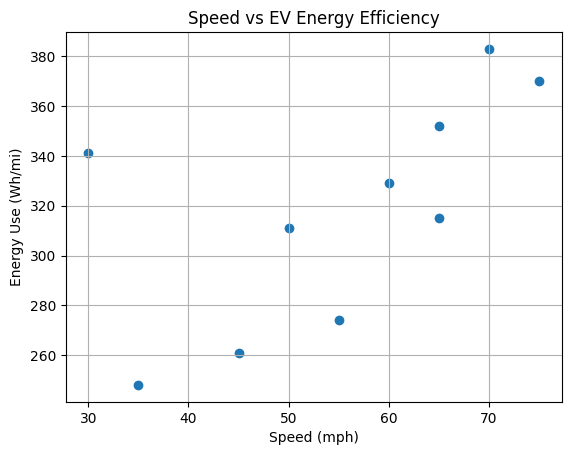

In [18]:
plt.scatter(df["speed_mph"], df["wh_per_mile"])
plt.xlabel("Speed (mph)")
plt.ylabel("Energy Use (Wh/mi)")
plt.title("Speed vs EV Energy Efficiency")
plt.grid(True)
plt.show()

In [22]:
print(df.columns)

Index(['trip_id', 'speed_mph', 'outside_temp_f', 'energy_used_kwh',
       'distance_miles', 'wh_per_mile'],
      dtype='str')


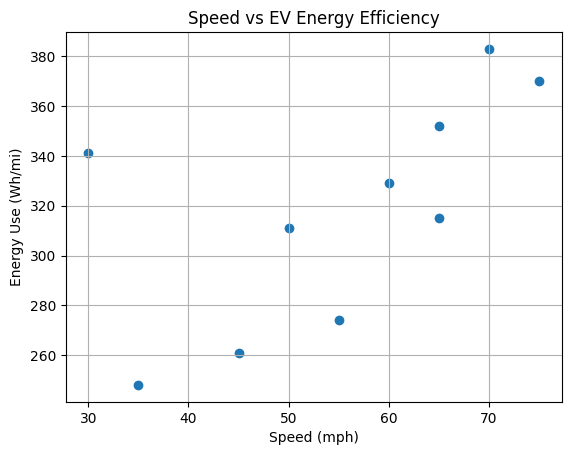

In [24]:
plt.scatter(df["speed_mph"], df["wh_per_mile"])

plt.xlabel("Speed (mph)")
plt.ylabel("Energy Use (Wh/mi)")
plt.title("Speed vs EV Energy Efficiency")
plt.grid(True)

plt.savefig("speed_vs_efficiency.png", dpi=300, bbox_inches="tight")
plt.show()

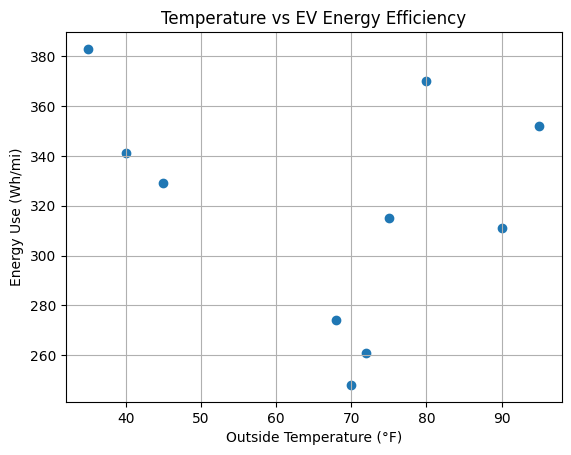

In [26]:
plt.scatter(df["outside_temp_f"], df["wh_per_mile"])
plt.xlabel("Outside Temperature (°F)")
plt.ylabel("Energy Use (Wh/mi)")
plt.title("Temperature vs EV Energy Efficiency")
plt.grid(True)

plt.savefig("temp_vs_efficiency.png", dpi=300, bbox_inches="tight")
plt.show()

Main findings:
1. Trips above 60 mph had higher Wh/mi than trips at or below 60 mph.
2. Higher Wh/mi means worse efficiency.
3. Speed appears to have a noticeable effect on energy use.
4. Temperature may also affect efficiency, but more data is needed.
